In [9]:
import polars as pl
import polars.selectors as cs
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df_my_sgd = pl.read_csv("results_mtp_my_sgd_torchlike.csv")
df_torch_sgd = pl.read_csv("results_mtp_torch_sgd.csv")

In [11]:
import polars as pl
import polars.selectors as cs


def compare_ensemble_stats_long(
    df1: pl.DataFrame, name1: str, df2: pl.DataFrame, name2: str
):
    m1 = df1.select(cs.numeric())
    m2 = df2.select(cs.numeric())

    common = [c for c in m1.columns if c in m2.columns]

    mean1 = m1.select(common).select(pl.all().mean()).row(0)
    mean2 = m2.select(common).select(pl.all().mean()).row(0)

    std1 = m1.select(common).select(pl.all().std()).row(0)
    std2 = m2.select(common).select(pl.all().std()).row(0)

    mean_df = pl.DataFrame(
        {
            "metric": common,
            "stat": ["mean"] * len(common),
            name1: list(mean1),
            name2: list(mean2),
        }
    )

    std_df = pl.DataFrame(
        {
            "metric": common,
            "stat": ["std"] * len(common),
            name1: list(std1),
            name2: list(std2),
        }
    )

    return mean_df, std_df


Сравниение самописного SGD и встроенного в Torch при одинаковых параметрах

In [12]:
display(df_my_sgd)
display(df_torch_sgd)


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss,losses,grad_norms,lrs
i64,f64,f64,f64,f64,f64,i64,i64,f64,str,str,str
1,0.200598,1.857881,0.411866,2.574736,126.791103,500,99,148.826851,"""[54190.74585623753, 51511.8752…","""[0.9999999999999999, 0.9999999…","""[0.001, 0.001, 0.001, 0.001, 0…"
2,0.107831,1.845533,0.172898,2.424575,126.220244,500,99,118.354928,"""[9841.108680574049, 9580.86935…","""[1.0, 0.9999999999999999, 1.0,…","""[0.001, 0.001, 0.001, 0.001, 0…"
3,0.135269,2.466432,0.261286,3.109684,126.141015,500,99,139.166867,"""[14641.021905540056, 14716.365…","""[1.0, 1.0000000000000002, 0.99…","""[0.001, 0.001, 0.001, 0.001, 0…"
4,0.156021,2.801026,0.227215,3.621565,126.544457,500,99,181.509284,"""[14806.949604572577, 14713.622…","""[1.0, 0.9999999999999999, 1.0,…","""[0.001, 0.001, 0.001, 0.001, 0…"
5,0.138423,1.645961,0.271796,2.297654,126.221606,500,99,96.798282,"""[8699.602951038964, 8811.73436…","""[0.9999999999999999, 1.0, 1.0,…","""[0.001, 0.001, 0.001, 0.001, 0…"


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,0.214418,1.867773,0.439982,2.590837,153.302085,500,100,148.826851
2,0.101324,1.84787,0.169899,2.430493,153.291253,500,100,118.354928
3,0.145857,2.472359,0.285079,3.106614,153.251174,500,100,139.166867
4,0.121781,2.865961,0.18758,3.67547,153.11852,500,100,181.509284
5,0.150826,1.625647,0.298209,2.270051,152.927128,500,100,96.798282


In [13]:
compare_ensemble_stats_long(df_my_sgd, "my sgd", df_torch_sgd, "torch sgd")

(shape: (9, 4)
 ┌───────────────────┬──────┬────────────┬────────────┐
 │ metric            ┆ stat ┆ my sgd     ┆ torch sgd  │
 │ ---               ┆ ---  ┆ ---        ┆ ---        │
 │ str               ┆ str  ┆ f64        ┆ f64        │
 ╞═══════════════════╪══════╪════════════╪════════════╡
 │ pot_num           ┆ mean ┆ 3.0        ┆ 3.0        │
 │ train_epa_rmse    ┆ mean ┆ 0.147628   ┆ 0.146841   │
 │ train_forces_rmse ┆ mean ┆ 2.123367   ┆ 2.135922   │
 │ val_epa_rmse      ┆ mean ┆ 0.269012   ┆ 0.27615    │
 │ val_forces_rmse   ┆ mean ┆ 2.805643   ┆ 2.814693   │
 │ train_time        ┆ mean ┆ 126.383685 ┆ 153.178032 │
 │ steps             ┆ mean ┆ 500.0      ┆ 500.0      │
 │ epochs            ┆ mean ┆ 99.0       ┆ 100.0      │
 │ final_loss        ┆ mean ┆ 136.931242 ┆ 136.931242 │
 └───────────────────┴──────┴────────────┴────────────┘,
 shape: (9, 4)
 ┌───────────────────┬──────┬───────────┬───────────┐
 │ metric            ┆ stat ┆ my sgd    ┆ torch sgd │
 │ ---               

Запуски производились на одинаковых seed, поэтому результаты показывают истинную картину. У my SGD валидационные ошибки получились лучше, а разброс меньше. Время обучения так же меньше в среднем на 27 секунд. Несмотря на это итоговый loss идентичный. Можно сделать вывод, что самописный SGD не уступает встроенному в torch, а значит можно смело его использовать.

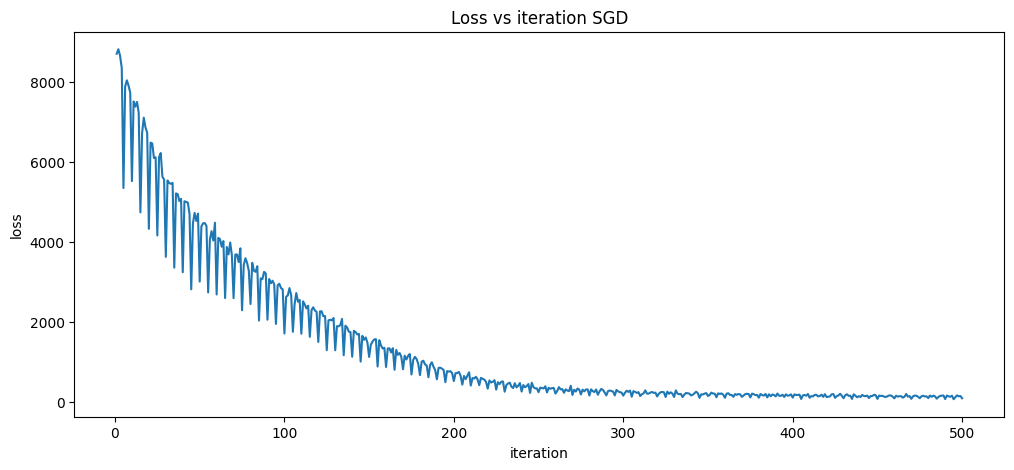

In [14]:
loss_history = json.loads(df_my_sgd[4]["losses"].item())
iters = np.arange(1, len(loss_history) + 1)


plt.figure(figsize=(12, 5))
plt.title("Loss vs iteration SGD")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.plot(iters, loss_history)

График изменения ошибки показывает нормальные для SGD колебания, а так же то, что начиная с ~300 итераций ошибка выходит на плато.

#### Эксперименты

##### Подбор clip и lr для SGD


In [15]:
df_my_sgd_clip_lr = pl.read_csv(
    "results_mtp_my_sgd_clip_lr_grid_experiment.csv"
)
df_my_sgd_batch_size = pl.read_csv("results_mtp_my_sgd_batch_size_experiment.csv")

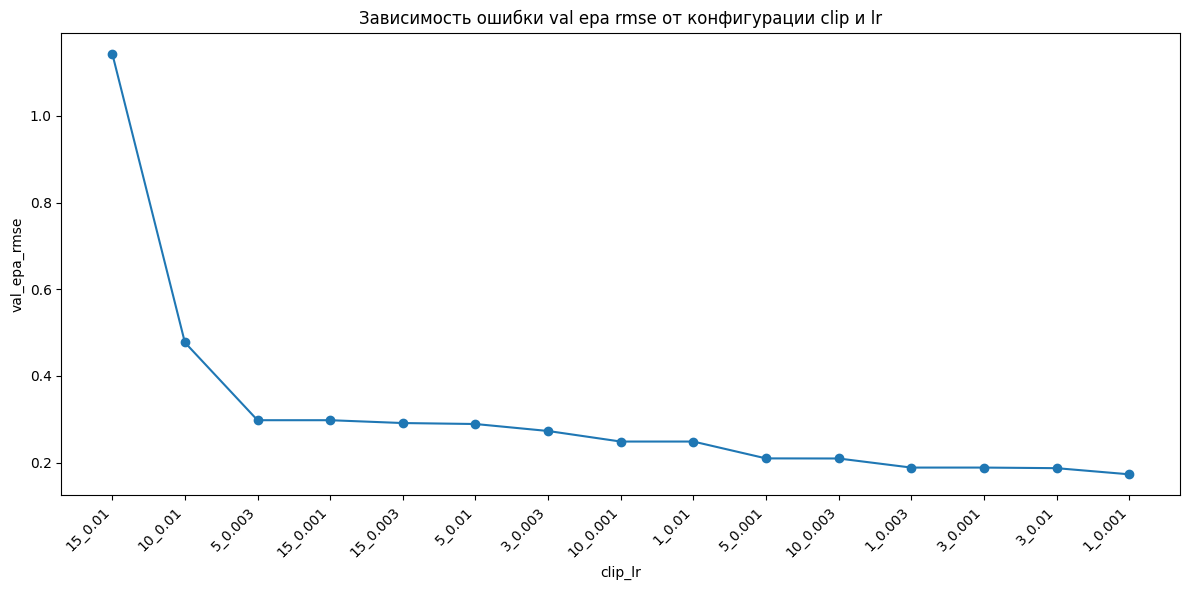

In [16]:
df_vis = (
    df_my_sgd_clip_lr.group_by(pl.col("clip"), pl.col("lr"))
    .mean()
    .with_columns(
        (pl.col("clip").cast(pl.Utf8) + "_" + pl.col("lr").cast(pl.Utf8)).alias(
            "clip_lr"
        )
    )
    .sort(pl.col("val_epa_rmse"), descending=True)
)


clip_lr = df_vis["clip_lr"].to_list()
y = df_vis["val_epa_rmse"].to_list()

plt.figure(figsize=(12, 6))
plt.title("Зависимость ошибки val epa rmse от конфигурации clip и lr")
plt.plot(clip_lr, y, marker="o")
plt.xticks(rotation=45, ha="right")
plt.xlabel("clip_lr")
plt.ylabel("val_epa_rmse")
plt.tight_layout()
plt.show()

##### Изменение размера батча

In [17]:
df_my_sgd_batch_size.head()


batch_size,max_steps,pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss,losses,grad_norms,lrs
i64,i64,i64,f64,f64,f64,f64,f64,i64,i64,f64,str,str,str
1,500,1,0.266101,2.549695,0.556823,3.588369,5.078704,500,3,5.369778,"""[1979.436206885993, 2051.87788…","""[0.9999999999999999, 0.9999999…","""[0.001, 0.001, 0.001, 0.001, 0…"
1,500,2,0.431172,3.822125,0.810338,4.392179,4.575619,500,3,26.127458,"""[293.1070101163853, 315.955555…","""[1.0, 1.0, 1.0000000000000002,…","""[0.001, 0.001, 0.001, 0.001, 0…"
1,500,3,0.41927,4.087407,0.656949,4.149698,4.575382,500,3,18.429384,"""[391.32184931734724, 421.51924…","""[1.0, 1.0, 1.0, 1.0, 0.9999999…","""[0.001, 0.001, 0.001, 0.001, 0…"
1,500,4,0.286144,3.612002,0.318955,4.666843,4.573256,500,3,32.757122,"""[470.49688214064554, 472.53249…","""[1.0, 1.0, 1.0, 1.0, 1.0, 1.0,…","""[0.001, 0.001, 0.001, 0.001, 0…"
1,500,5,0.192987,3.055525,0.346195,4.489929,4.564439,500,3,9.609079,"""[306.3010882847472, 304.343762…","""[1.0, 1.0, 0.9999999999999999,…","""[0.001, 0.001, 0.001, 0.001, 0…"


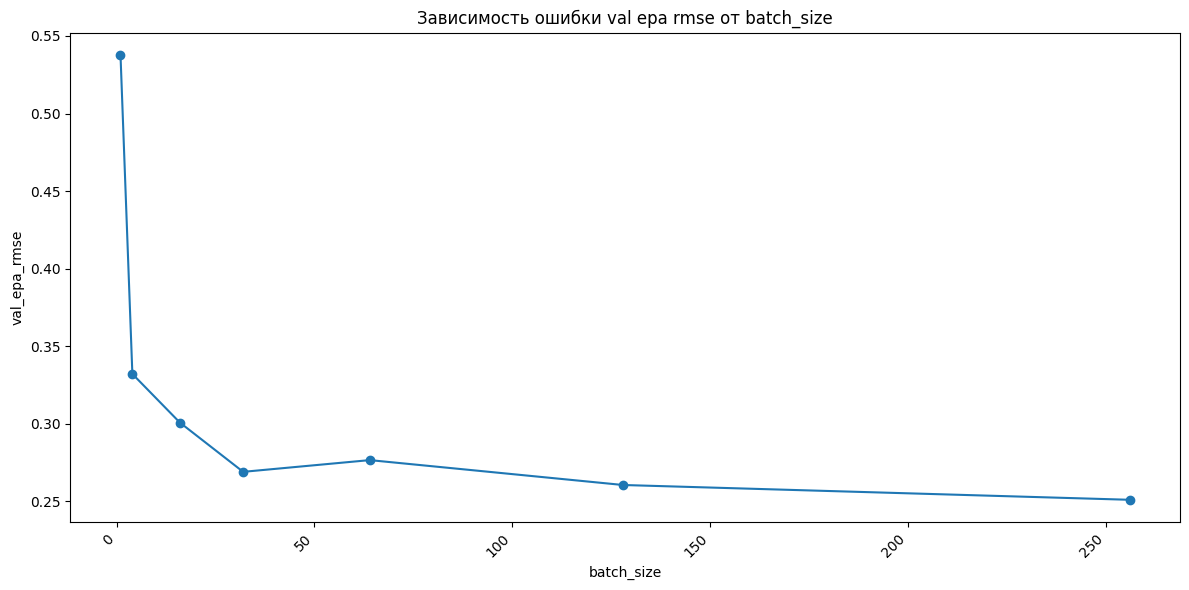

In [18]:
df_temp = df_my_sgd_batch_size.group_by(["batch_size"]).mean()


batch_size = df_temp["batch_size"].to_list()
y = df_temp["val_epa_rmse"].to_list()

plt.figure(figsize=(12, 6))
plt.title("Зависимость ошибки val epa rmse от batch_size")
plt.plot(batch_size, y, marker="o")
plt.xticks(rotation=45, ha="right")
plt.xlabel("batch_size")
plt.ylabel("val_epa_rmse")
plt.tight_layout()
plt.show()


Вывод: SGD выдает слабый результат на этой задаче, по сравнению с bfgs. Стоит опробовать другие методы.

#### Momentum mtp


In [19]:
from polars import selectors as cs

df_my_momentum = pl.read_csv("results_mtp_my_momentum.csv")
print("Mean")
display(df_my_momentum.select(cs.numeric()).mean()[:, 1:])
print("Std")
display(df_my_momentum.select(cs.numeric()).std()[:, 1:])

Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.045323,1.034435,0.070682,1.483861,362.41786,1500.0,299.0,27.831455


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.013894,0.124004,0.018186,0.149247,0.180097,0.0,0.0,8.552473


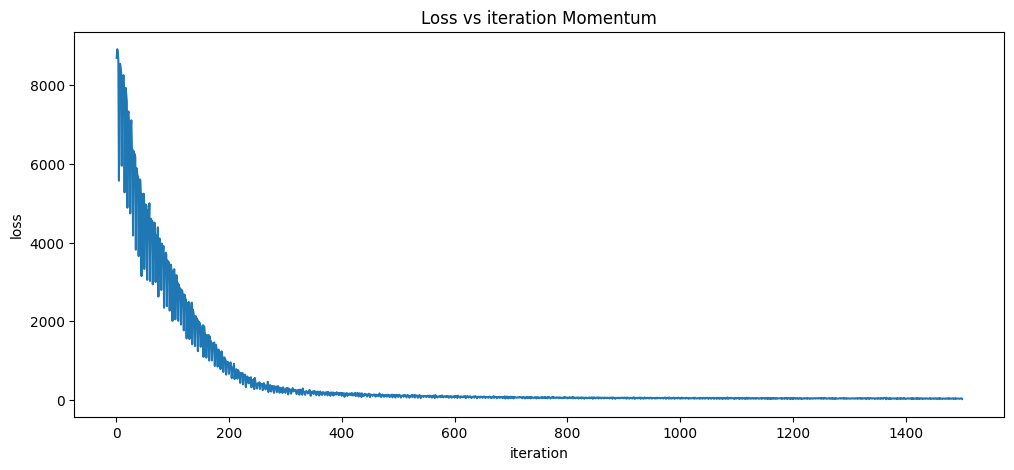

In [20]:
loss_history = json.loads(df_my_momentum[4]["losses"].item())
iters = np.arange(1, len(loss_history) + 1)


plt.figure(figsize=(12, 5))
plt.title("Loss vs iteration Momentum")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.plot(iters, loss_history)

#### Adam mtp

In [21]:
from polars import selectors as cs

df_my_adam= pl.read_csv("results_mtp_my_adam.csv")
print("Mean")
display(df_my_adam.select(cs.numeric()).mean()[:, 1:])
print("Std")
display(df_my_adam.select(cs.numeric()).std()[:, 1:])


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.054409,0.490837,0.057803,0.782384,390.73522,1500.0,299.0,8.878885


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.012364,0.053439,0.010997,0.071061,6.899867,0.0,0.0,5.360207


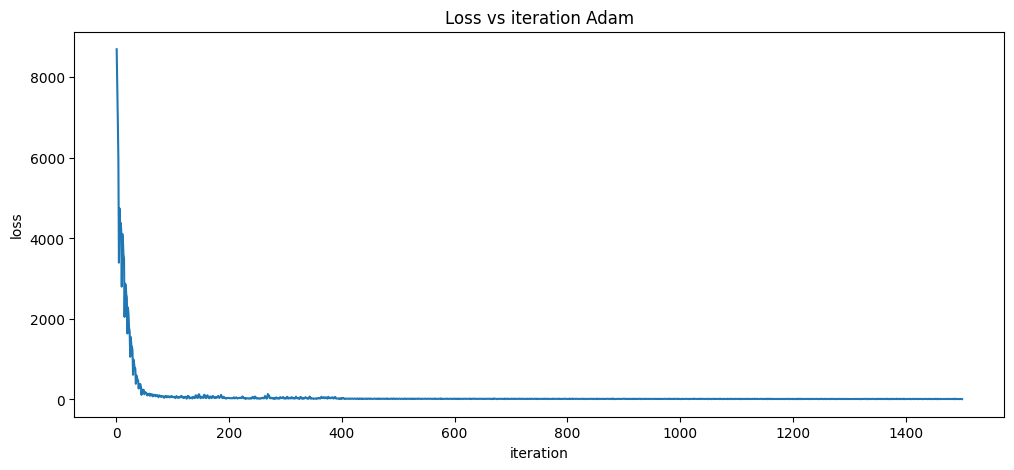

In [22]:
loss_history = json.loads(df_my_adam[4]["losses"].item())
iters = np.arange(1, len(loss_history) + 1)


plt.figure(figsize=(12, 5))
plt.title("Loss vs iteration Adam")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.plot(iters, loss_history)


Как видно из графикоф обучения, Adam и Momentum оба обучатся менее шумно, чем mini-batch sgd, но быстро упираются в плато, и ошибка не меняется. 
Как это, возможно, решается: 
1) Отрегулировать clipping. Сейчас текущие обучения применяют клиппинг градиента до единичной нормы, что позволяет нормировать нестабильный на первых шагах градиент и не улетать в бесколнечность. Но на поздних итерациях постоянный клиппинг может мешать, потому что теряется информация о масштабе градиента, и шаг перестаёт адаптироваться к близости к минимуму.
2) Отрегулировать lr. Если lr (или эффективный шаг lr·clip) слишком мал, прогресс после выхода на плато становится крайне медленным. Если слишком велик — начинаются колебания/рост loss и возможна численная нестабильность.
3) Дообучать на LBFGS. LBFGS оптимизатор второго порядка и лучше учитывает кривизну функции. 

### Эксперименты с Adam на MTP

In [23]:
def without_history(df):
    cols = [c for c in ["losses", "grad_norms", "lrs"] if c in df.columns]
    return df.drop(cols)


def show_mean_std(df):
    if df.height == 0:
        print("Нет строк с результатами")
        display(df)
        return

    numeric = df.select(cs.numeric())
    cols = [c for c in numeric.columns if c != "pot_num"]

    print("Mean")
    display(numeric.select(cols).mean())
    print("Std")
    display(numeric.select(cols).std())


def plot_loss_compare(items, title):
    plt.figure(figsize=(12, 5))
    plt.title(title)
    plt.xlabel("iteration")
    plt.ylabel("loss")

    for label, df in items:
        loss_history = json.loads(df[4]["losses"].item())
        iters = np.arange(1, len(loss_history) + 1)
        plt.plot(iters, loss_history, label=label)

    plt.legend()
    plt.tight_layout()
    plt.show()


##### Эксперимент: schedule для clipping

In [24]:
df_mtp_adam_clip_schedule = pl.read_csv("results_mtp_adam_clip_schedule.csv")

display(without_history(df_mtp_adam_clip_schedule))
show_mean_std(df_mtp_adam_clip_schedule)


pot_num,clip_warmup,warmup_steps,clip_main,total_steps,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,i64,f64,i64,f64,f64,f64,f64,f64,i64,i64,f64
1,1.0,200,10.0,1500,0.054458,0.432133,0.055828,0.692036,371.681007,1500,298,5.07351
2,1.0,200,10.0,1500,0.065546,0.396288,0.06095,0.640125,372.472895,1500,298,9.060949
3,1.0,200,10.0,1500,0.070483,0.511042,0.080605,0.794511,369.711586,1500,298,8.965086
4,1.0,200,10.0,1500,0.043589,0.341416,0.040985,0.557044,370.303142,1500,298,5.619399
5,1.0,200,10.0,1500,0.037838,0.457958,0.042626,0.730283,370.654221,1500,298,4.278524


Mean


clip_warmup,warmup_steps,clip_main,total_steps,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,200.0,10.0,1500.0,0.054383,0.427767,0.056199,0.6828,370.96457,1500.0,298.0,6.599494


Std


clip_warmup,warmup_steps,clip_main,total_steps,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.013911,0.063861,0.016078,0.090077,1.105905,0.0,0.0,2.25449


In [25]:
compare_mean, compare_std = compare_ensemble_stats_long(
    df_my_adam,
    "default Adam",
    df_mtp_adam_clip_schedule,
    "Adam clip schedule",
)

display(compare_mean)
display(compare_std)


metric,stat,default Adam,Adam clip schedule
str,str,f64,f64
"""pot_num""","""mean""",3.0,3.0
"""train_epa_rmse""","""mean""",0.054409,0.054383
"""train_forces_rmse""","""mean""",0.490837,0.427767
"""val_epa_rmse""","""mean""",0.057803,0.056199
"""val_forces_rmse""","""mean""",0.782384,0.6828
"""train_time""","""mean""",390.73522,370.96457
"""steps""","""mean""",1500.0,1500.0
"""epochs""","""mean""",299.0,298.0
"""final_loss""","""mean""",8.878885,6.599494


metric,stat,default Adam,Adam clip schedule
str,str,f64,f64
"""pot_num""","""std""",1.581139,1.581139
"""train_epa_rmse""","""std""",0.012364,0.013911
"""train_forces_rmse""","""std""",0.053439,0.063861
"""val_epa_rmse""","""std""",0.010997,0.016078
"""val_forces_rmse""","""std""",0.071061,0.090077
"""train_time""","""std""",6.899867,1.105905
"""steps""","""std""",0.0,0.0
"""epochs""","""std""",0.0,0.0
"""final_loss""","""std""",5.360207,2.25449


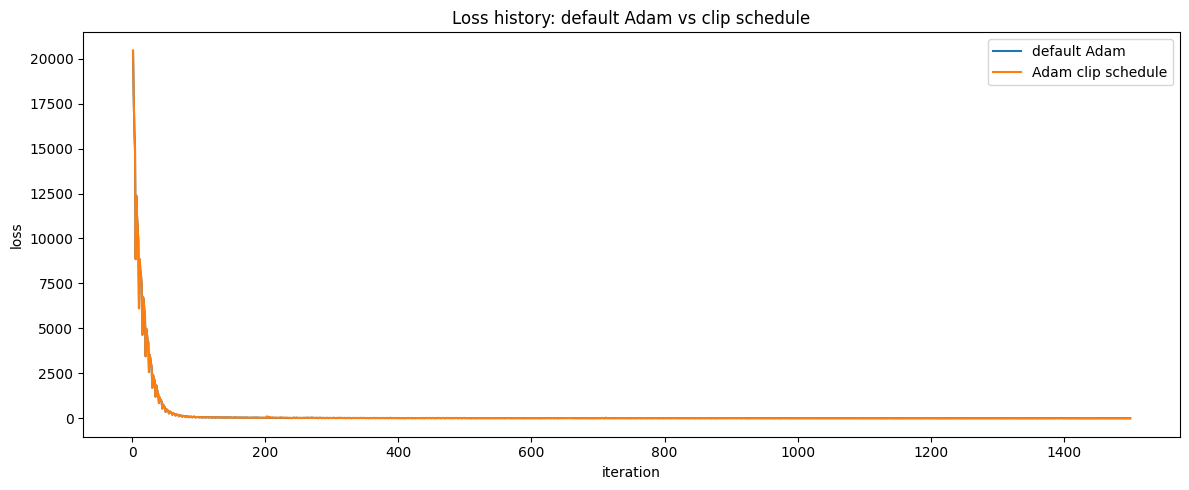

In [26]:
def mean_loss_history(df):
    histories = [json.loads(x) for x in df["losses"].to_list()]
    min_len = min(len(x) for x in histories)
    histories = np.array([x[:min_len] for x in histories])
    return histories.mean(axis=0)

adam_loss = mean_loss_history(df_my_adam)
clip_schedule_loss = mean_loss_history(df_mtp_adam_clip_schedule)
iters = np.arange(1, len(adam_loss) + 1)

plt.figure(figsize=(12, 5))
plt.title("Loss history: default Adam vs clip schedule")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.plot(iters, adam_loss, label="default Adam")
plt.plot(iters, clip_schedule_loss, label="Adam clip schedule")
plt.legend()
plt.tight_layout()
plt.show()


Вывод: schedule для clip немного улучшил val forces rmse и final loss, но по val epa rmse почти не изменил результат относительно default Adam. Значит сам по себе другой clipping не решает плато полностью.

##### Эксперимент: подбор lr

In [27]:
df_mtp_adam_lr_grid = pl.read_csv("results_mtp_adam_lr_grid.csv")

lr_results = (
    df_mtp_adam_lr_grid
    .group_by("lr")
    .mean()
    .select([
        "lr",
        "train_epa_rmse",
        "train_forces_rmse",
        "val_epa_rmse",
        "val_forces_rmse",
        "train_time",
        "final_loss",
    ])
    .sort("val_epa_rmse")
)

display(lr_results)


lr,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,final_loss
f64,f64,f64,f64,f64,f64,f64
0.0003,0.031301,0.597013,0.038218,0.935425,491.381603,8.14084
0.003,0.054457,0.365657,0.052535,0.575934,491.942554,7.021208
0.001,0.054409,0.490837,0.057803,0.782384,492.539866,8.878885
0.01,0.058069,0.232418,0.062533,0.345188,492.64234,1.749939


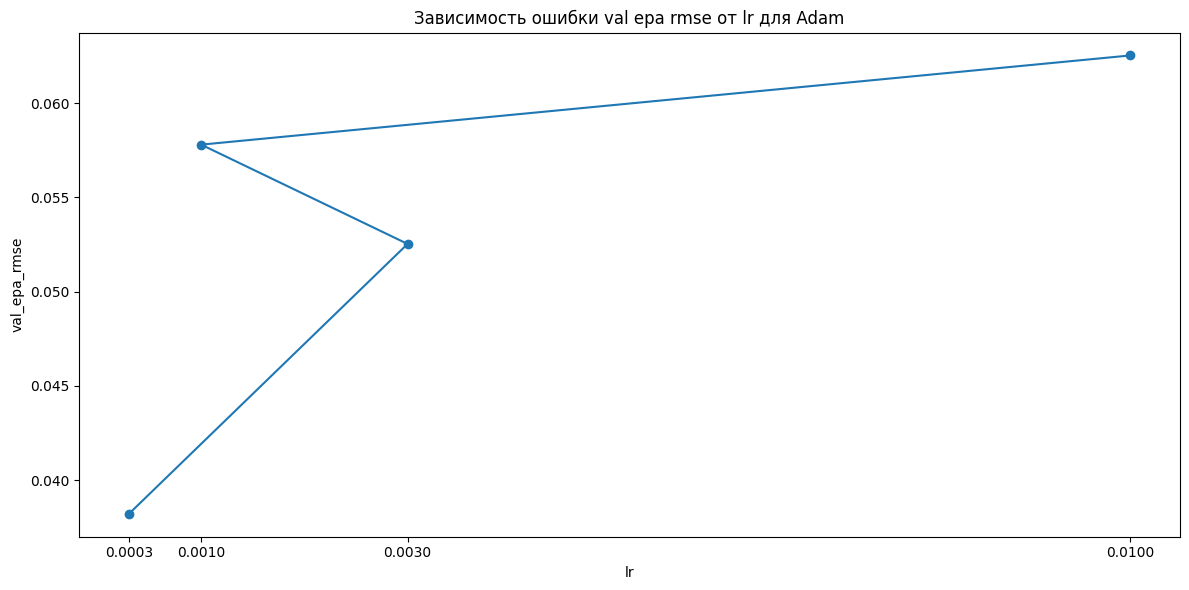

In [28]:
lr = lr_results["lr"].to_list()
y = lr_results["val_epa_rmse"].to_list()

plt.figure(figsize=(12, 6))
plt.title("Зависимость ошибки val epa rmse от lr для Adam")
plt.plot(lr, y, marker="o")
plt.xticks(lr)
plt.xlabel("lr")
plt.ylabel("val_epa_rmse")
plt.tight_layout()
plt.show()


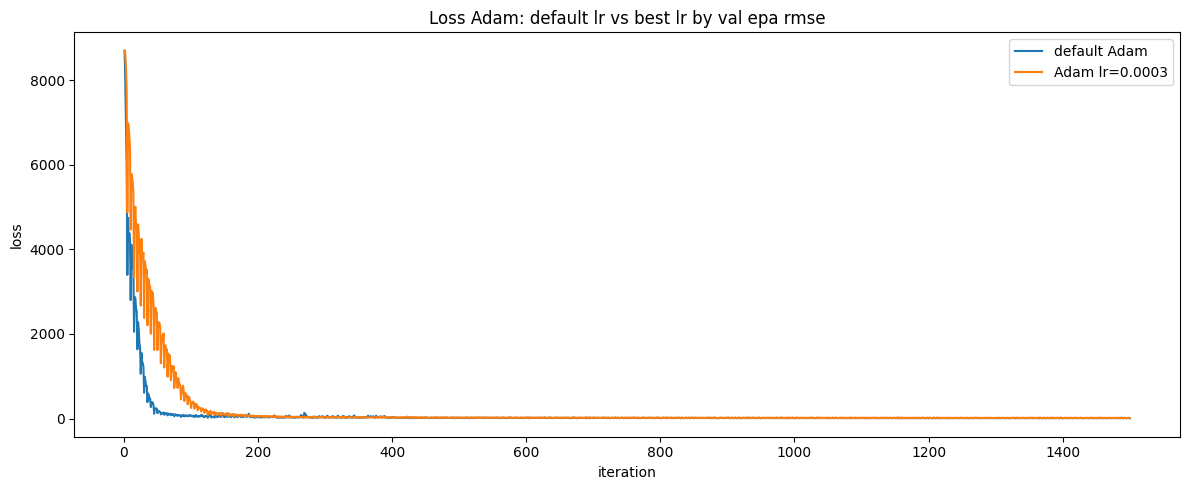

In [29]:
best_lr = lr_results[0]["lr"].item()
df_best_lr = df_mtp_adam_lr_grid.filter(pl.col("lr") == best_lr)

plot_loss_compare(
    [
        ("default Adam", df_my_adam),
        (f"Adam lr={best_lr}", df_best_lr),
    ],
    "Loss Adam: default lr vs best lr by val epa rmse",
)


Вывод: лучший lr по val epa rmse получился 0.0003. При этом lr=0.01 лучше по force-ошибке и final loss, но хуже по epa. Поэтому для сравнения по основной epa-ошибке я дальше считаю лучшим lr=0.0003.

##### Эксперимент: Adam + LBFGS

In [30]:
df_mtp_adam_then_lbfgs = pl.read_csv("results_mtp_adam_then_lbfgs.csv")

display(df_mtp_adam_then_lbfgs)
show_mean_std(df_mtp_adam_then_lbfgs)


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,time_adam,steps_adam,epochs_adam,final_loss_adam,time_lbfgs,nit,success,final_loss_lbfgs
i64,f64,f64,f64,f64,f64,i64,i64,f64,f64,i64,i64,f64
1,0.012255,0.425385,0.023393,0.684971,205.496405,800,159,18.659827,285.443558,300,0,23.417427
2,0.010458,0.37894,0.018818,0.622829,204.255006,800,159,8.408057,320.781469,300,0,22.889449
3,0.009048,0.314878,0.016059,0.493397,274.12939,800,159,15.324908,332.488044,300,0,15.546024
4,0.008895,0.334878,0.016292,0.545193,236.632081,800,159,9.200542,319.401785,300,0,16.944536
5,0.010604,0.384911,0.019188,0.646767,305.527073,800,159,7.907443,291.985627,300,0,22.711875


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,time_adam,steps_adam,epochs_adam,final_loss_adam,time_lbfgs,nit,success,final_loss_lbfgs
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.010252,0.367798,0.01875,0.598631,245.207991,800.0,159.0,11.900155,310.020097,300.0,0.0,20.301862


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,time_adam,steps_adam,epochs_adam,final_loss_adam,time_lbfgs,nit,success,final_loss_lbfgs
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.001367,0.043639,0.00296,0.077922,44.166,0.0,0.0,4.817844,20.235367,0.0,0.0,3.745002


In [31]:
df_lbfgs_for_compare = (
    df_mtp_adam_then_lbfgs
    .with_columns([
        (pl.col("time_adam") + pl.col("time_lbfgs")).alias("train_time"),
        (pl.col("steps_adam") + pl.col("nit")).alias("steps"),
        pl.col("epochs_adam").alias("epochs"),
        pl.col("final_loss_lbfgs").alias("final_loss"),
    ])
    .select([
        "pot_num",
        "train_epa_rmse",
        "train_forces_rmse",
        "val_epa_rmse",
        "val_forces_rmse",
        "train_time",
        "steps",
        "epochs",
        "final_loss",
    ])
)

compare_mean, compare_std = compare_ensemble_stats_long(
    df_my_adam,
    "default Adam",
    df_lbfgs_for_compare,
    "Adam + LBFGS",
)

display(compare_mean)
display(compare_std)


metric,stat,default Adam,Adam + LBFGS
str,str,f64,f64
"""pot_num""","""mean""",3.0,3.0
"""train_epa_rmse""","""mean""",0.054409,0.010252
"""train_forces_rmse""","""mean""",0.490837,0.367798
"""val_epa_rmse""","""mean""",0.057803,0.01875
"""val_forces_rmse""","""mean""",0.782384,0.598631
"""train_time""","""mean""",390.73522,555.228088
"""steps""","""mean""",1500.0,1100.0
"""epochs""","""mean""",299.0,159.0
"""final_loss""","""mean""",8.878885,20.301862


metric,stat,default Adam,Adam + LBFGS
str,str,f64,f64
"""pot_num""","""std""",1.581139,1.581139
"""train_epa_rmse""","""std""",0.012364,0.001367
"""train_forces_rmse""","""std""",0.053439,0.043639
"""val_epa_rmse""","""std""",0.010997,0.00296
"""val_forces_rmse""","""std""",0.071061,0.077922
"""train_time""","""std""",6.899867,48.667235
"""steps""","""std""",0.0,0.0
"""epochs""","""std""",0.0,0.0
"""final_loss""","""std""",5.360207,3.745002


Вывод: дообучение LBFGS дало самое заметное улучшение по val epa rmse. Success везде False, потому что оптимизатор упирался в ограничение nit=300, но даже так ошибки стали ниже, чем у default Adam.

##### Сравнение Adam + LBFGS и чистого BFGS

In [32]:
df_mtp_scipy_bfgs = pl.read_csv("../../task3/results/results_mtp_scipy_bfgs_001.csv")

df_bfgs_for_compare = (
    df_mtp_scipy_bfgs
    .rename({
        "train_energy_atom_rmse": "train_epa_rmse",
        "val_energy_atom_rmse": "val_epa_rmse",
    })
    .with_columns([
        pl.col("nit").alias("steps"),
        pl.col("final_loss").alias("final_loss"),
    ])
    .select([
        "pot_num",
        "train_epa_rmse",
        "train_forces_rmse",
        "val_epa_rmse",
        "val_forces_rmse",
        "train_time",
        "steps",
        "final_loss",
    ])
)

display(df_bfgs_for_compare)
show_mean_std(df_bfgs_for_compare)


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,final_loss
i64,f64,f64,f64,f64,f64,i64,f64
1,0.00153,0.041701,0.002777,0.07243,321.804864,500,0.179231
2,0.001369,0.038913,0.002834,0.069618,321.957178,500,0.210109
3,0.00137,0.036641,0.002709,0.063014,330.634391,500,0.195722
4,0.001411,0.038805,0.002782,0.067986,319.621238,500,0.243943
5,0.001518,0.041818,0.00296,0.074671,324.818725,500,0.269577


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,final_loss
f64,f64,f64,f64,f64,f64,f64
0.001439,0.039576,0.002813,0.069544,323.767279,500.0,0.219717


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,final_loss
f64,f64,f64,f64,f64,f64,f64
0.000079,0.002191,0.000094,0.004463,4.259694,0.0,0.036675


In [33]:
compare_mean, compare_std = compare_ensemble_stats_long(
    df_lbfgs_for_compare,
    "Adam + LBFGS",
    df_bfgs_for_compare,
    "BFGS",
)

display(compare_mean)
display(compare_std)


metric,stat,Adam + LBFGS,BFGS
str,str,f64,f64
"""pot_num""","""mean""",3.0,3.0
"""train_epa_rmse""","""mean""",0.010252,0.001439
"""train_forces_rmse""","""mean""",0.367798,0.039576
"""val_epa_rmse""","""mean""",0.01875,0.002813
"""val_forces_rmse""","""mean""",0.598631,0.069544
"""train_time""","""mean""",555.228088,323.767279
"""steps""","""mean""",1100.0,500.0
"""final_loss""","""mean""",20.301862,0.219717


metric,stat,Adam + LBFGS,BFGS
str,str,f64,f64
"""pot_num""","""std""",1.581139,1.581139
"""train_epa_rmse""","""std""",0.001367,0.000079
"""train_forces_rmse""","""std""",0.043639,0.002191
"""val_epa_rmse""","""std""",0.00296,0.000094
"""val_forces_rmse""","""std""",0.077922,0.004463
"""train_time""","""std""",48.667235,4.259694
"""steps""","""std""",0.0,0.0
"""final_loss""","""std""",3.745002,0.036675


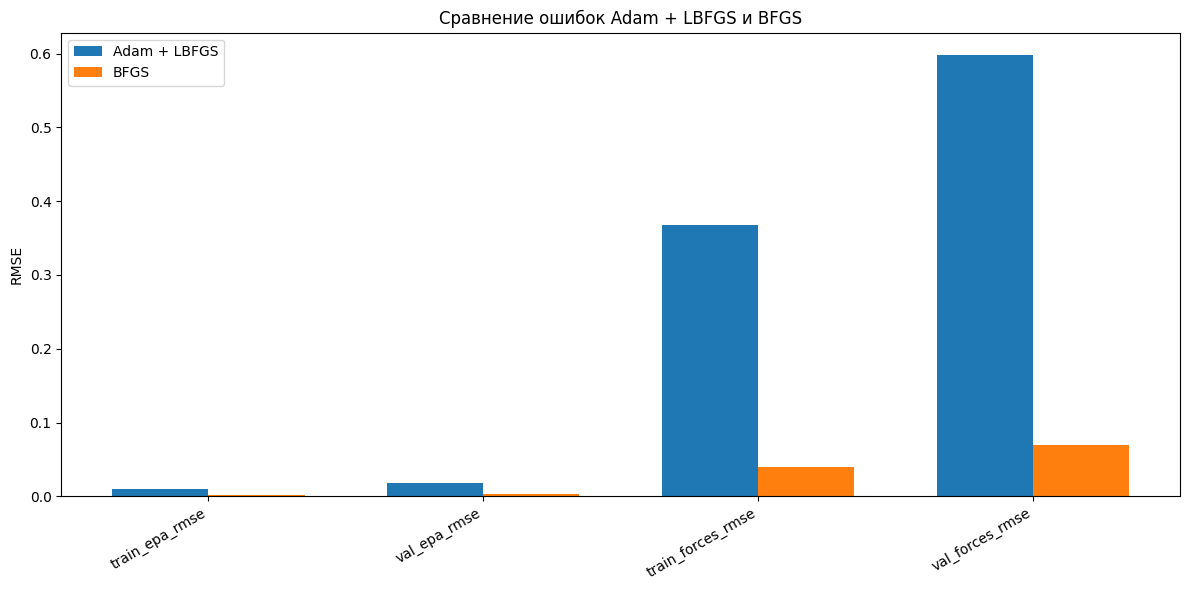

In [34]:
metrics = ["train_epa_rmse", "val_epa_rmse", "train_forces_rmse", "val_forces_rmse"]
adam_lbfgs_errors = [df_lbfgs_for_compare[m].mean() for m in metrics]
bfgs_errors = [df_bfgs_for_compare[m].mean() for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12, 6))
plt.title("Сравнение ошибок Adam + LBFGS и BFGS")
plt.bar(x - width / 2, adam_lbfgs_errors, width, label="Adam + LBFGS")
plt.bar(x + width / 2, bfgs_errors, width, label="BFGS")
plt.xticks(x, metrics, rotation=30, ha="right")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()


Вывод: чистый BFGS из task3 здесь сильно лучше по всем статистикам.

#### ETN для базовых оптимизаторов

In [35]:
from pathlib import Path


def read_results_if_exists(filename):
    path = Path(filename)
    if not path.exists():
        print(f"Файл {filename} не найден")
        return None
    return pl.read_csv(path)


def show_optimizer_etn_results(df, title):
    print(title)

    if df is None:
        return

    display(without_history(df))
    show_mean_std(df)

    if df.height == 0:
        return

    if "losses" in df.columns:
        loss_history = json.loads(df[0]["losses"].item())
        iters = np.arange(1, len(loss_history) + 1)

        plt.figure(figsize=(12, 5))
        plt.title(f"Loss vs iteration {title}")
        plt.xlabel("iteration")
        plt.ylabel("loss")
        plt.plot(iters, loss_history)
        plt.tight_layout()
        plt.show()

#### Adam etn

Adam ETN


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,0.02644,0.728369,0.042411,1.060287,384.035203,1500,299,13.417378
2,0.027541,0.732097,0.044058,1.065147,383.16601,1500,299,13.038524
3,0.027423,0.727215,0.044279,1.057648,387.403009,1500,299,14.382557
4,0.027034,0.71907,0.043448,1.046742,382.933285,1500,299,15.603346
5,0.02845,0.743011,0.048521,1.080046,382.85571,1500,299,16.433974


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.027378,0.729952,0.044543,1.061974,384.078643,1500.0,299.0,14.575156


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.000738,0.008711,0.002339,0.012147,1.916612,0.0,0.0,1.436242


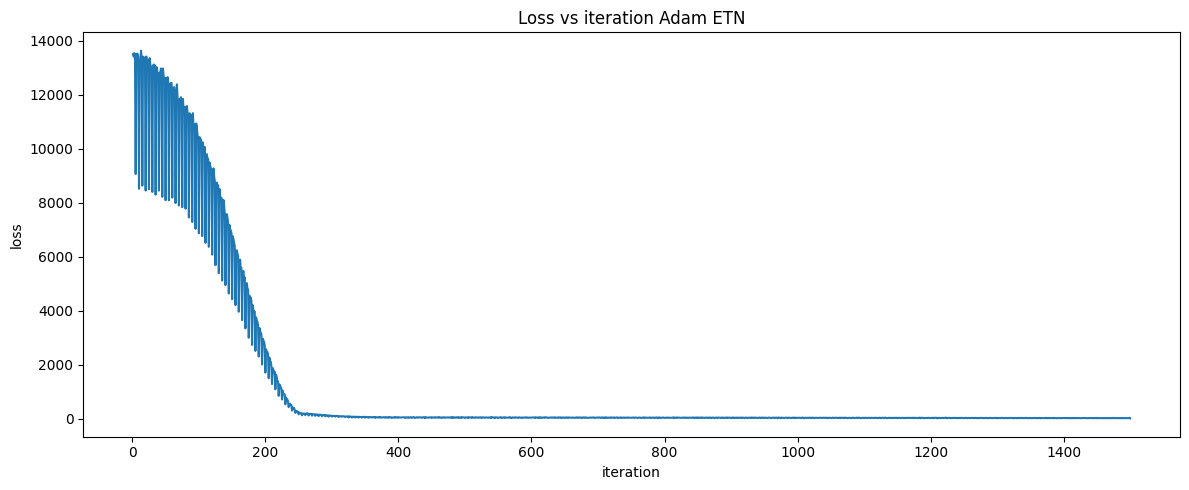

In [36]:
df_etn_my_adam = read_results_if_exists("results_etn_my_adam.csv")
show_optimizer_etn_results(df_etn_my_adam, "Adam ETN")


Вывод: для ETN Adam сейчас дает лучший результат среди доступных ETN запусков.

#### Momentum etn

Momentum ETN


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,1.79967,1.402845,1.635574,1.731212,307.115818,1500,299,2237.559687
2,1.819844,1.401044,1.65629,1.729945,306.266205,1500,299,2312.092739
3,1.759824,1.401206,1.596229,1.730001,307.442175,1500,299,2092.894906
4,1.698126,1.395041,1.536318,1.726353,308.78995,1500,299,2003.52934
5,1.925078,1.400742,1.761669,1.729863,305.090335,1500,299,2523.707041


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
1.800509,1.400176,1.637216,1.729475,306.940896,1500.0,299.0,2233.956742


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.08371,0.002984,0.08324,0.001831,1.37665,0.0,0.0,201.908816


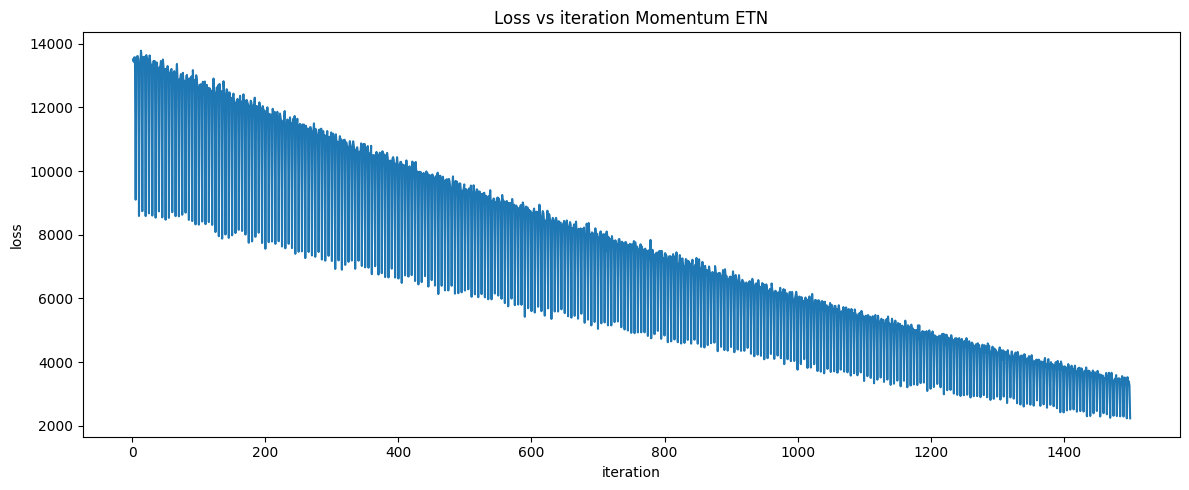

In [37]:
df_etn_my_momentum = read_results_if_exists("results_etn_my_momentum.csv")
show_optimizer_etn_results(df_etn_my_momentum, "Momentum ETN")


#### SGD etn

SGD ETN


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,3.013018,1.402907,2.850153,1.731155,131.073901,500,99,6202.516214
2,3.031838,1.401087,2.869565,1.729979,130.699173,500,99,6284.762676
3,2.972729,1.401487,2.810341,1.730206,133.448823,500,99,6002.645745
4,2.915506,1.399363,2.753738,1.72891,129.145841,500,99,5849.61443
5,3.138241,1.401347,2.975957,1.730199,132.039339,500,99,6623.191711


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
3.014266,1.401238,2.851951,1.73009,131.281415,500.0,99.0,6192.546155


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.0824,0.001265,0.082262,0.000801,1.598034,0.0,0.0,294.840303


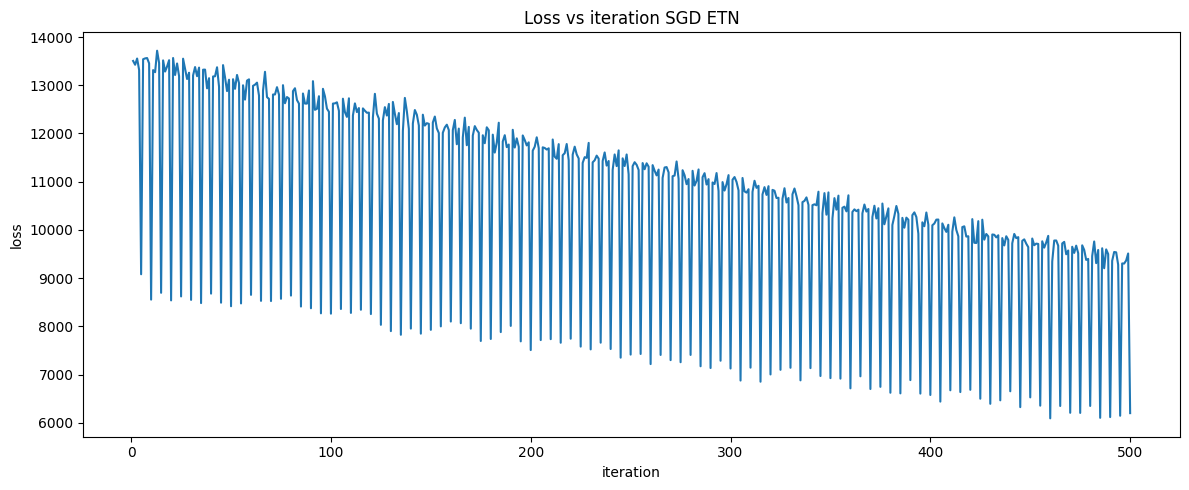

In [38]:
df_etn_my_sgd = read_results_if_exists("results_etn_my_sgd_torchlike.csv")
show_optimizer_etn_results(df_etn_my_sgd, "SGD ETN")


#### Muon

##### Muon pad sqrt: MTP

In [39]:
df_mtp_my_muon_pad_sqrt = pl.read_csv("results_mtp_my_muon_pad_sqrt.csv")
df_mtp_my_muon = df_mtp_my_muon_pad_sqrt

display(without_history(df_mtp_my_muon_pad_sqrt))
show_mean_std(df_mtp_my_muon_pad_sqrt)


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,0.083944,0.420177,0.076045,0.67064,479.281292,1500,299,16.565008
2,0.117878,0.561541,0.115689,0.811756,480.95348,1500,299,6.654175
3,0.076101,0.558643,0.073413,0.840666,477.216054,1500,299,17.098683
4,0.104627,0.570567,0.102371,0.890564,483.555779,1500,299,19.943736
5,0.092054,0.451642,0.095507,0.707138,477.3532,1500,299,14.312931


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.094921,0.512514,0.092605,0.784153,479.671961,1500.0,299.0,14.914907


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.016614,0.070946,0.017883,0.092325,2.65928,0.0,0.0,5.034454


In [40]:
compare_mean, compare_std = compare_ensemble_stats_long(
    df_my_adam,
    "Adam MTP",
    df_mtp_my_muon_pad_sqrt,
    "Muon pad sqrt MTP",
)

display(compare_mean)
display(compare_std)


metric,stat,Adam MTP,Muon pad sqrt MTP
str,str,f64,f64
"""pot_num""","""mean""",3.0,3.0
"""train_epa_rmse""","""mean""",0.054409,0.094921
"""train_forces_rmse""","""mean""",0.490837,0.512514
"""val_epa_rmse""","""mean""",0.057803,0.092605
"""val_forces_rmse""","""mean""",0.782384,0.784153
"""train_time""","""mean""",390.73522,479.671961
"""steps""","""mean""",1500.0,1500.0
"""epochs""","""mean""",299.0,299.0
"""final_loss""","""mean""",8.878885,14.914907


metric,stat,Adam MTP,Muon pad sqrt MTP
str,str,f64,f64
"""pot_num""","""std""",1.581139,1.581139
"""train_epa_rmse""","""std""",0.012364,0.016614
"""train_forces_rmse""","""std""",0.053439,0.070946
"""val_epa_rmse""","""std""",0.010997,0.017883
"""val_forces_rmse""","""std""",0.071061,0.092325
"""train_time""","""std""",6.899867,2.65928
"""steps""","""std""",0.0,0.0
"""epochs""","""std""",0.0,0.0
"""final_loss""","""std""",5.360207,5.034454


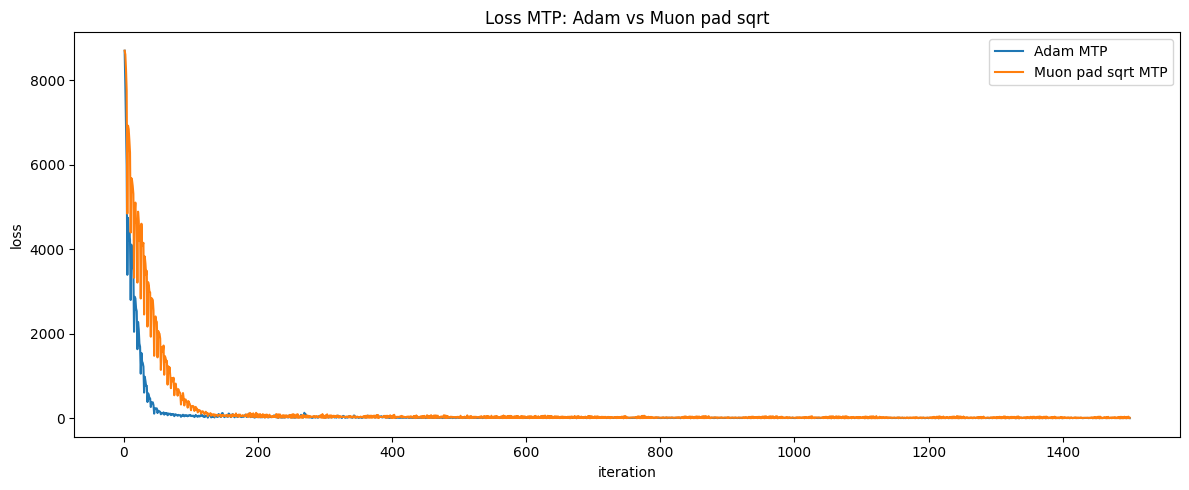

In [41]:
plot_loss_compare(
    [
        ("Adam MTP", df_my_adam),
        ("Muon pad sqrt MTP", df_mtp_my_muon_pad_sqrt),
    ],
    "Loss MTP: Adam vs Muon pad sqrt",
)


Вывод: для MTP Muon pad sqrt проигрывает Adam по val epa rmse и final loss. По force-ошибке результат близкий к default Adam, но хуже, чем у лучших lr/LBFGS экспериментов.

##### Muon factorization: MTP

In [42]:
df_mtp_my_muon_factorization = pl.read_csv("results_mtp_my_muon_factorization.csv")

display(without_history(df_mtp_my_muon_factorization))
show_mean_std(df_mtp_my_muon_factorization)


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,0.133834,0.499478,0.132201,0.727924,476.643745,1500,299,33.365017
2,0.123946,0.585755,0.130312,0.912237,476.640076,1500,299,21.909656
3,0.085082,0.598257,0.087477,0.882523,475.643593,1500,299,8.373331
4,0.146368,0.58878,0.13914,0.916974,478.638329,1500,299,16.584721
5,0.154928,0.434393,0.155002,0.686343,476.273133,1500,299,4.036353


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.128832,0.541333,0.128827,0.8252,476.767775,1500.0,299.0,16.853816


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.027164,0.071856,0.025074,0.109576,1.122399,0.0,0.0,11.559192


In [43]:
compare_mean, compare_std = compare_ensemble_stats_long(
    df_mtp_my_muon_pad_sqrt,
    "Muon pad sqrt MTP",
    df_mtp_my_muon_factorization,
    "Muon factorization MTP",
)

display(compare_mean)
display(compare_std)


metric,stat,Muon pad sqrt MTP,Muon factorization MTP
str,str,f64,f64
"""pot_num""","""mean""",3.0,3.0
"""train_epa_rmse""","""mean""",0.094921,0.128832
"""train_forces_rmse""","""mean""",0.512514,0.541333
"""val_epa_rmse""","""mean""",0.092605,0.128827
"""val_forces_rmse""","""mean""",0.784153,0.8252
"""train_time""","""mean""",479.671961,476.767775
"""steps""","""mean""",1500.0,1500.0
"""epochs""","""mean""",299.0,299.0
"""final_loss""","""mean""",14.914907,16.853816


metric,stat,Muon pad sqrt MTP,Muon factorization MTP
str,str,f64,f64
"""pot_num""","""std""",1.581139,1.581139
"""train_epa_rmse""","""std""",0.016614,0.027164
"""train_forces_rmse""","""std""",0.070946,0.071856
"""val_epa_rmse""","""std""",0.017883,0.025074
"""val_forces_rmse""","""std""",0.092325,0.109576
"""train_time""","""std""",2.65928,1.122399
"""steps""","""std""",0.0,0.0
"""epochs""","""std""",0.0,0.0
"""final_loss""","""std""",5.034454,11.559192


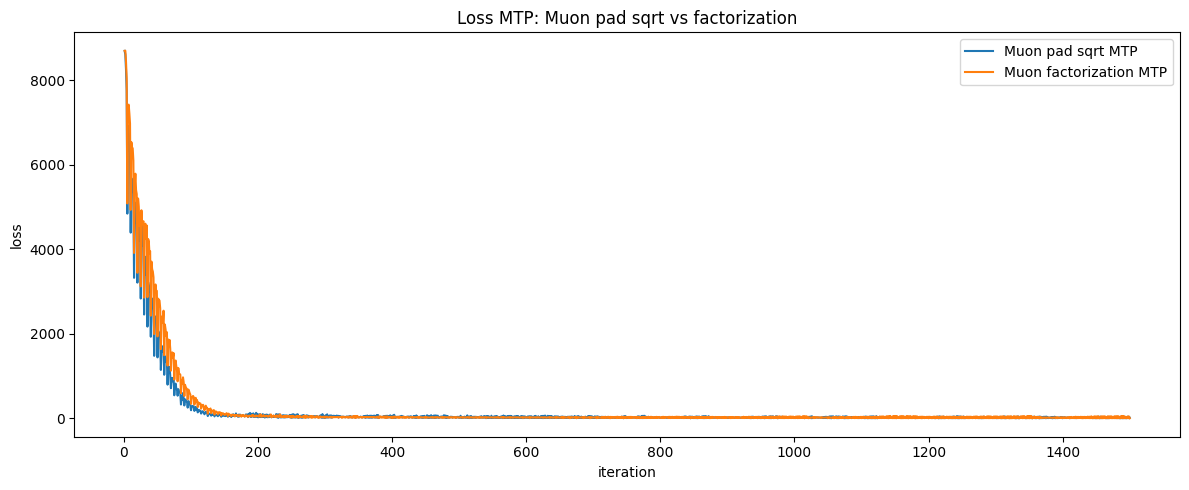

In [44]:
plot_loss_compare(
    [
        ("Muon pad sqrt MTP", df_mtp_my_muon_pad_sqrt),
        ("Muon factorization MTP", df_mtp_my_muon_factorization),
    ],
    "Loss MTP: Muon pad sqrt vs factorization",
)


Вывод: на MTP вариант factorization оказался хуже pad sqrt по val epa rmse, val forces rmse и final loss. То есть для MTP pad sqrt выглядит более удачной версией Muon.

##### Muon pad sqrt: ETN

In [45]:
df_etn_my_muon_pad_sqrt = pl.read_csv("results_etn_my_muon_pad_sqrt.csv")
df_etn_my_muon = df_etn_my_muon_pad_sqrt

display(without_history(df_etn_my_muon_pad_sqrt))
show_mean_std(df_etn_my_muon_pad_sqrt)


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,0.059978,1.240417,0.092895,1.628699,396.547929,1500,299,44.414827
2,0.160698,1.268237,0.180671,1.657727,394.810418,1500,299,50.125706
3,0.068914,1.211318,0.106224,1.614001,393.894563,1500,299,36.73218
4,0.02883,1.156282,0.041495,1.581548,395.219581,1500,299,32.347983
5,0.656373,1.182966,0.58739,1.596418,393.629679,1500,299,330.362212


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.194959,1.211844,0.201735,1.615679,394.820434,1500.0,299.0,98.796582


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.262575,0.044492,0.221257,0.02948,1.163915,0.0,0.0,129.63051


In [46]:
compare_mean, compare_std = compare_ensemble_stats_long(
    df_etn_my_adam,
    "Adam ETN",
    df_etn_my_muon_pad_sqrt,
    "Muon pad sqrt ETN",
)

display(compare_mean)
display(compare_std)


metric,stat,Adam ETN,Muon pad sqrt ETN
str,str,f64,f64
"""pot_num""","""mean""",3.0,3.0
"""train_epa_rmse""","""mean""",0.027378,0.194959
"""train_forces_rmse""","""mean""",0.729952,1.211844
"""val_epa_rmse""","""mean""",0.044543,0.201735
"""val_forces_rmse""","""mean""",1.061974,1.615679
"""train_time""","""mean""",384.078643,394.820434
"""steps""","""mean""",1500.0,1500.0
"""epochs""","""mean""",299.0,299.0
"""final_loss""","""mean""",14.575156,98.796582


metric,stat,Adam ETN,Muon pad sqrt ETN
str,str,f64,f64
"""pot_num""","""std""",1.581139,1.581139
"""train_epa_rmse""","""std""",0.000738,0.262575
"""train_forces_rmse""","""std""",0.008711,0.044492
"""val_epa_rmse""","""std""",0.002339,0.221257
"""val_forces_rmse""","""std""",0.012147,0.02948
"""train_time""","""std""",1.916612,1.163915
"""steps""","""std""",0.0,0.0
"""epochs""","""std""",0.0,0.0
"""final_loss""","""std""",1.436242,129.63051


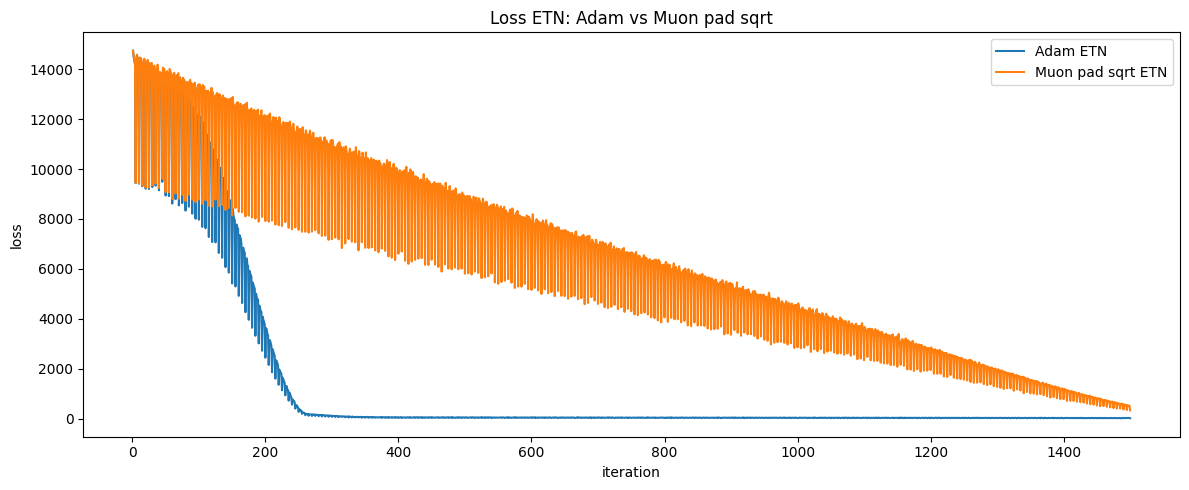

In [47]:
plot_loss_compare(
    [
        ("Adam ETN", df_etn_my_adam),
        ("Muon pad sqrt ETN", df_etn_my_muon_pad_sqrt),
    ],
    "Loss ETN: Adam vs Muon pad sqrt",
)


Вывод: для ETN Muon pad sqrt заметно хуже Adam по обеим validation-ошибкам.

##### Muon factorization: ETN

In [48]:
df_etn_my_muon_factorization = pl.read_csv("results_etn_my_muon_factorization.csv")

display(without_history(df_etn_my_muon_factorization))
show_mean_std(df_etn_my_muon_factorization)


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,0.032852,1.065314,0.057618,1.481617,292.368485,1500,299,28.205491
2,0.033757,1.134973,0.058963,1.565597,297.181866,1500,299,27.822954
3,0.035122,1.134292,0.063688,1.563744,299.690426,1500,299,33.667196
4,0.030505,0.998742,0.051381,1.399013,300.079237,1500,299,28.295644
5,0.040808,1.09738,0.076229,1.522649,301.204356,1500,299,32.601988


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.034609,1.08614,0.061576,1.506524,298.104874,1500.0,299.0,30.118655


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.003852,0.056793,0.009295,0.069287,3.52764,0.0,0.0,2.784461


In [49]:
compare_mean, compare_std = compare_ensemble_stats_long(
    df_etn_my_muon_pad_sqrt,
    "Muon pad sqrt ETN",
    df_etn_my_muon_factorization,
    "Muon factorization ETN",
)

display(compare_mean)
display(compare_std)


metric,stat,Muon pad sqrt ETN,Muon factorization ETN
str,str,f64,f64
"""pot_num""","""mean""",3.0,3.0
"""train_epa_rmse""","""mean""",0.194959,0.034609
"""train_forces_rmse""","""mean""",1.211844,1.08614
"""val_epa_rmse""","""mean""",0.201735,0.061576
"""val_forces_rmse""","""mean""",1.615679,1.506524
"""train_time""","""mean""",394.820434,298.104874
"""steps""","""mean""",1500.0,1500.0
"""epochs""","""mean""",299.0,299.0
"""final_loss""","""mean""",98.796582,30.118655


metric,stat,Muon pad sqrt ETN,Muon factorization ETN
str,str,f64,f64
"""pot_num""","""std""",1.581139,1.581139
"""train_epa_rmse""","""std""",0.262575,0.003852
"""train_forces_rmse""","""std""",0.044492,0.056793
"""val_epa_rmse""","""std""",0.221257,0.009295
"""val_forces_rmse""","""std""",0.02948,0.069287
"""train_time""","""std""",1.163915,3.52764
"""steps""","""std""",0.0,0.0
"""epochs""","""std""",0.0,0.0
"""final_loss""","""std""",129.63051,2.784461


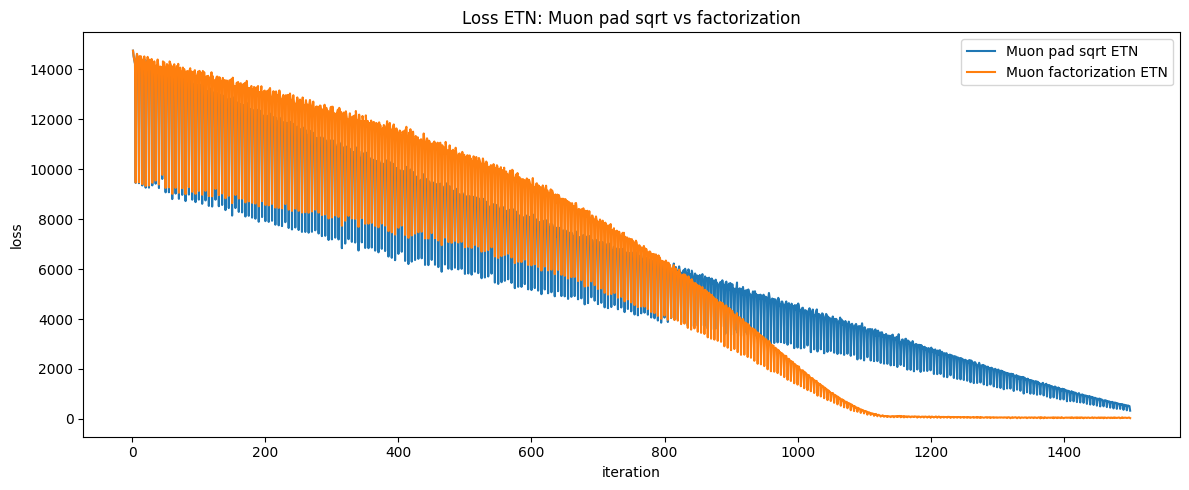

In [50]:
plot_loss_compare(
    [
        ("Muon pad sqrt ETN", df_etn_my_muon_pad_sqrt),
        ("Muon factorization ETN", df_etn_my_muon_factorization),
    ],
    "Loss ETN: Muon pad sqrt vs factorization",
)


Вывод: для ETN factorization значительно лучше pad sqrt по val epa rmse и final loss. При этом Adam все равно остается сильнее по ETN validation-ошибкам.

#### Общее сравнение всех методов

In [51]:
def method_summary(method_name, df):
    numeric_cols = [
        "train_epa_rmse",
        "train_forces_rmse",
        "val_epa_rmse",
        "val_forces_rmse",
        "train_time",
        "steps",
        "epochs",
        "final_loss",
    ]
    data = {"method": method_name}

    for col in numeric_cols:
        if col in df.columns:
            data[f"{col}_mean"] = df[col].mean()
            data[f"{col}_std"] = df[col].std()

    return data


def methods_summary(methods):
    return pl.DataFrame([method_summary(name, df) for name, df in methods])


def plot_methods_comparison(summary, title):
    methods = summary["method"].to_list()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title)

    axes[0].bar(methods, summary["val_epa_rmse_mean"].to_list())
    axes[0].set_title("val_epa_rmse")
    axes[0].set_ylabel("RMSE")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(methods, summary["val_forces_rmse_mean"].to_list())
    axes[1].set_title("val_forces_rmse")
    axes[1].set_ylabel("RMSE")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def plot_methods_loss_history(methods, title):
    plt.figure(figsize=(12, 6))
    plt.title(title)
    plt.xlabel("iteration")
    plt.ylabel("loss")

    plotted = False
    for name, df in methods:
        if df is None or df.height == 0 or "losses" not in df.columns:
            print(f"Для {name} нет loss history в CSV")
            continue

        loss_history = mean_loss_history(df)
        iters = np.arange(1, len(loss_history) + 1)
        plt.plot(iters, loss_history, label=name)
        plotted = True

    if plotted:
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        plt.close()
        print("Нет методов с сохраненной историей loss")


##### Общее сравнение MTP

method,train_epa_rmse_mean,train_epa_rmse_std,train_forces_rmse_mean,train_forces_rmse_std,val_epa_rmse_mean,val_epa_rmse_std,val_forces_rmse_mean,val_forces_rmse_std,train_time_mean,train_time_std,steps_mean,steps_std,epochs_mean,epochs_std,final_loss_mean,final_loss_std
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BFGS""",0.001439,0.000079,0.039576,0.002191,0.002813,0.000094,0.069544,0.004463,323.767279,4.259694,500.0,0.0,null,null,0.219717,0.036675
"""Adam + LBFGS""",0.010252,0.001367,0.367798,0.043639,0.01875,0.00296,0.598631,0.077922,555.228088,48.667235,1100.0,0.0,159.0,0.0,20.301862,3.745002
"""Adam lr=0.0003""",0.031301,0.006461,0.597013,0.063137,0.038218,0.006557,0.935425,0.088557,491.381603,3.001156,1500.0,0.0,299.0,0.0,8.14084,1.488524
"""Adam clip schedule""",0.054383,0.013911,0.427767,0.063861,0.056199,0.016078,0.6828,0.090077,370.96457,1.105905,1500.0,0.0,298.0,0.0,6.599494,2.25449
"""Adam""",0.054409,0.012364,0.490837,0.053439,0.057803,0.010997,0.782384,0.071061,390.73522,6.899867,1500.0,0.0,299.0,0.0,8.878885,5.360207
"""Momentum""",0.045323,0.013894,1.034435,0.124004,0.070682,0.018186,1.483861,0.149247,362.41786,0.180097,1500.0,0.0,299.0,0.0,27.831455,8.552473
"""Muon pad sqrt""",0.094921,0.016614,0.512514,0.070946,0.092605,0.017883,0.784153,0.092325,479.671961,2.65928,1500.0,0.0,299.0,0.0,14.914907,5.034454
"""Muon factorization""",0.128832,0.027164,0.541333,0.071856,0.128827,0.025074,0.8252,0.109576,476.767775,1.122399,1500.0,0.0,299.0,0.0,16.853816,11.559192
"""SGD""",0.147628,0.034269,2.123367,0.487982,0.269012,0.088684,2.805643,0.551079,126.383685,0.275549,500.0,0.0,99.0,0.0,136.931242,31.974362


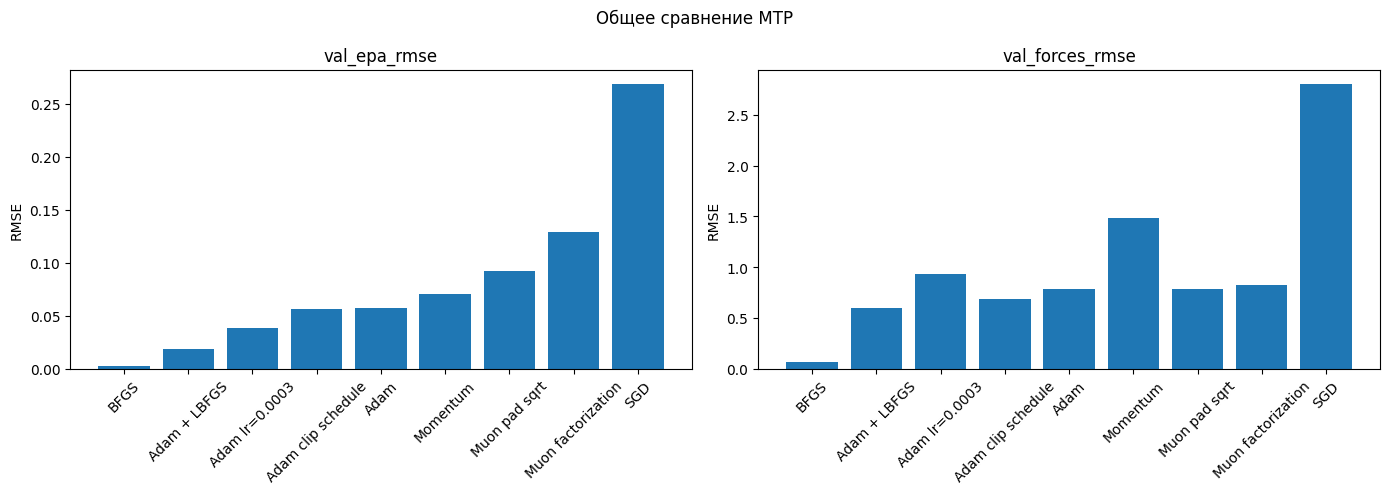

Для Adam + LBFGS нет loss history в CSV
Для BFGS нет loss history в CSV


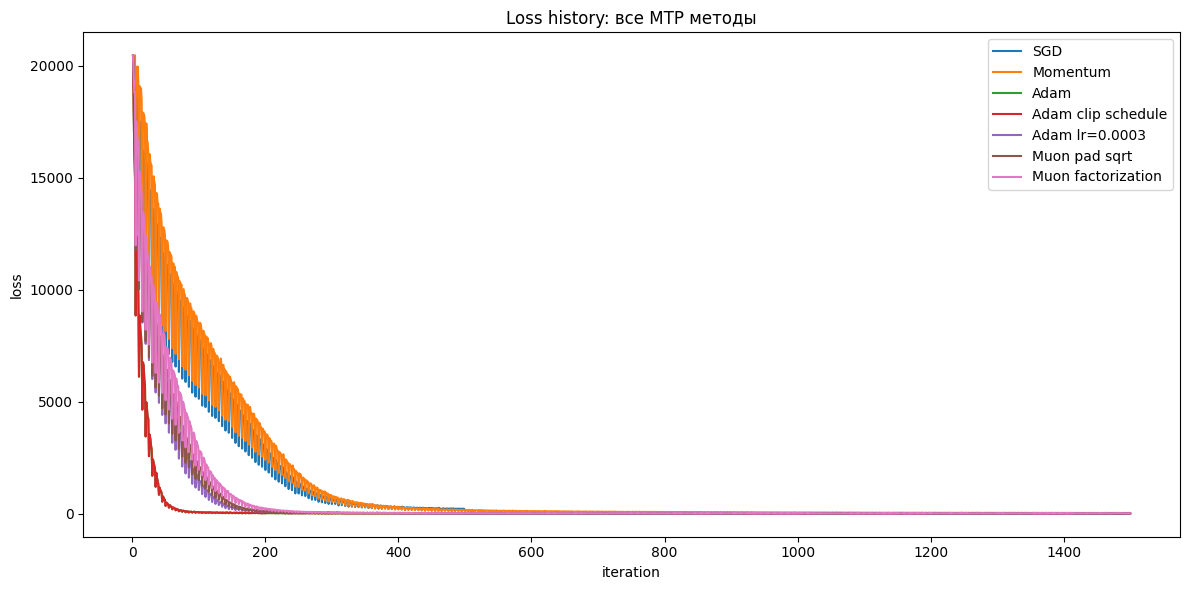

In [52]:
mtp_methods = [
    ("SGD", df_my_sgd),
    ("Momentum", df_my_momentum),
    ("Adam", df_my_adam),
    ("Adam clip schedule", df_mtp_adam_clip_schedule),
    (f"Adam lr={best_lr}", df_best_lr),
    ("Adam + LBFGS", df_lbfgs_for_compare),
    ("BFGS", df_bfgs_for_compare),
    ("Muon pad sqrt", df_mtp_my_muon_pad_sqrt),
    ("Muon factorization", df_mtp_my_muon_factorization),
]

mtp_summary = methods_summary(mtp_methods).sort("val_epa_rmse_mean")

display(mtp_summary)
plot_methods_comparison(mtp_summary, "Общее сравнение MTP")
plot_methods_loss_history(mtp_methods, "Loss history: все MTP методы")


Вывод: по MTP лучшими по val epa rmse получились методы второго порядка: чистый BFGS и Adam + LBFGS. Среди mini-batch методов лучше всего выглядит Adam с подобранным lr, а обе версии Muon проигрывают лучшим Adam/BFGS вариантам.

##### Общее сравнение ETN

In [53]:
import polars as pl
df_etn_scipy_bfgs = pl.read_csv("/Users/peterzarenkov/projects/course_work/Testing-optimization-methods-in-MLP/task1/results/results_etn.csv")

df_bfgs_for_compare_etn = (

    df_etn_scipy_bfgs
    .rename({
        "train_energy_atom_rmse": "train_epa_rmse",
        "val_energy_atom_rmse": "val_epa_rmse",
    })
    .select([
        "pot_num",
        "train_epa_rmse",
        "train_forces_rmse",
        "val_epa_rmse",
        "val_forces_rmse",
        "train_time",
    ])
)

method,train_epa_rmse_mean,train_epa_rmse_std,train_forces_rmse_mean,train_forces_rmse_std,val_epa_rmse_mean,val_epa_rmse_std,val_forces_rmse_mean,val_forces_rmse_std,train_time_mean,train_time_std,steps_mean,steps_std,epochs_mean,epochs_std,final_loss_mean,final_loss_std
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BFGS""",0.008614,7.7751e-12,0.191736,6.7849e-11,0.013874,3.9209e-11,0.277115,1.7161e-10,63.497188,12.634197,null,null,null,null,null,null
"""Adam""",0.027378,0.000738,0.729952,0.008711,0.044543,0.002339,1.061974,0.012147,384.078643,1.916612,1500.0,0.0,299.0,0.0,14.575156,1.436242
"""Muon factorization""",0.034609,0.003852,1.08614,0.056793,0.061576,0.009295,1.506524,0.069287,298.104874,3.52764,1500.0,0.0,299.0,0.0,30.118655,2.784461
"""Muon pad sqrt""",0.194959,0.262575,1.211844,0.044492,0.201735,0.221257,1.615679,0.02948,394.820434,1.163915,1500.0,0.0,299.0,0.0,98.796582,129.63051
"""Momentum""",1.800509,0.08371,1.400176,0.002984,1.637216,0.08324,1.729475,0.001831,306.940896,1.37665,1500.0,0.0,299.0,0.0,2233.956742,201.908816
"""SGD""",3.014266,0.0824,1.401238,0.001265,2.851951,0.082262,1.73009,0.000801,131.281415,1.598034,500.0,0.0,99.0,0.0,6192.546155,294.840303


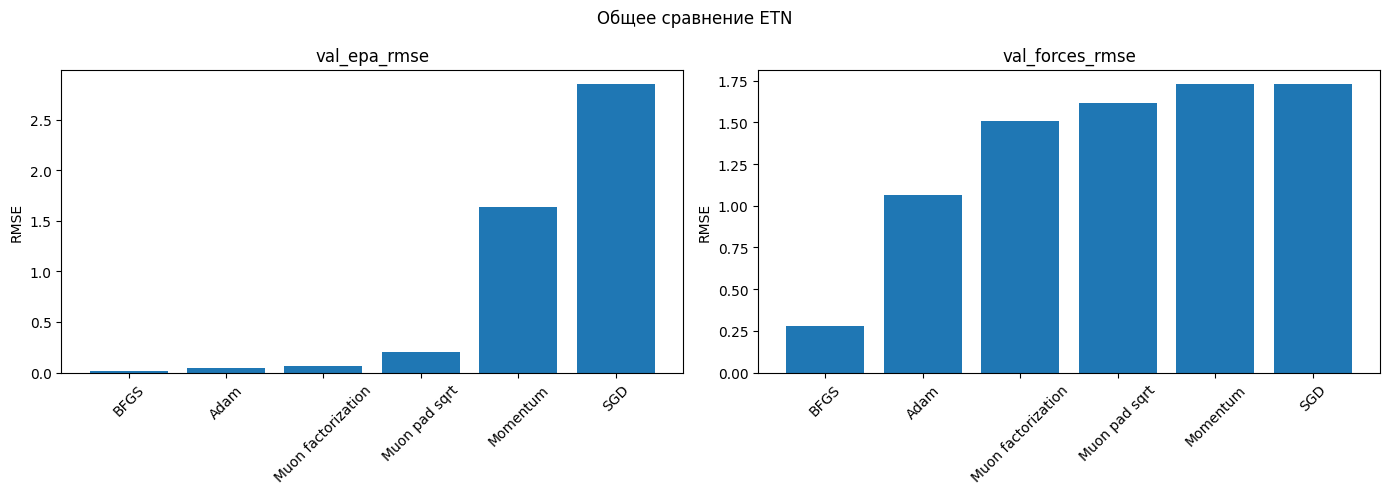

Для BFGS нет loss history в CSV


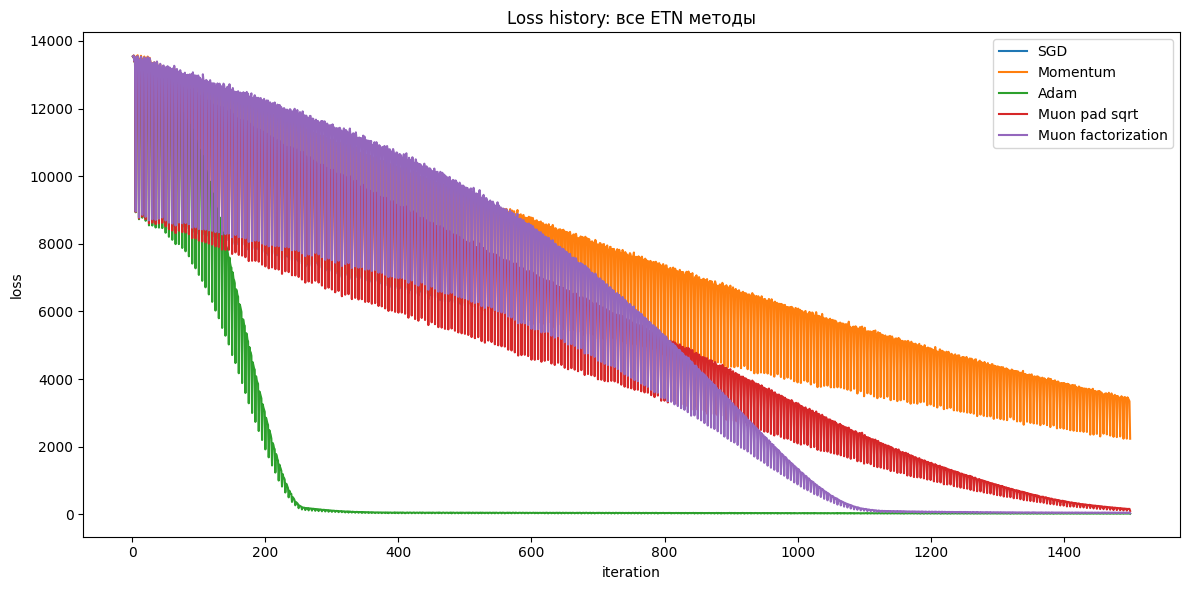

In [54]:
etn_methods = [
    ("BFGS", df_bfgs_for_compare_etn),
    ("SGD", df_etn_my_sgd),
    ("Momentum", df_etn_my_momentum),
    ("Adam", df_etn_my_adam),
    ("Muon pad sqrt", df_etn_my_muon_pad_sqrt),
    ("Muon factorization", df_etn_my_muon_factorization),
]

etn_methods = [(name, df) for name, df in etn_methods if df is not None and df.height > 0]
etn_summary = methods_summary(etn_methods).sort("val_epa_rmse_mean")

display(etn_summary)
plot_methods_comparison(etn_summary, "Общее сравнение ETN")
plot_methods_loss_history(etn_methods, "Loss history: все ETN методы")


Вывод: по ETN лучшим остается Adam. Muon factorization заметно лучше Muon pad sqrt, но до Adam не дотягивает. Momentum и SGD на ETN дают сильно худшие energy-ошибки.